# Copernicus Marine — Sea Water Salinity, Gulf of Tunisia

**Product:** `MEDSEA_MULTIYEAR_PHY_006_004`  
**Dataset:** `cmems_mod_med_phy-sal_my_4.2km_P1D-m`  
**Variable:** `so` — sea water practical salinity (PSU) at 1 m depth  
**Period:** 2026-01-01 → 2026-03-31  
**Domain:** Gulf of Tunisia — lon 10°–10.9°E, lat 36.6°–37.2°N  
**Model:** Mediterranean Sea Physics Reanalysis (MFS E3R1I, 4.2 km, daily mean)

In [1]:
#%pip install copernicusmarine hvplot matplotlib xarray --quiet

In [3]:
import copernicusmarine

# Saves credentials to ~/.copernicusmarine so you are not prompted again
copernicusmarine.login(
    username="nmkhinini",
    password="Nadiamkh73261260?",  # <-- replace with your Copernicus Marine password
    force_overwrite=True,
)

INFO - 2026-04-22T15:05:23Z - Credentials file stored in /home/jovyan/.copernicusmarine/.copernicusmarine-credentials.


True

## 1. Open the salinity dataset (lazy, no download yet)

In [4]:
import warnings
warnings.filterwarnings("ignore")

ds_sal = copernicusmarine.open_dataset(
    dataset_id="cmems_mod_med_phy-sal_my_4.2km_P1D-m",
    variables=["so"],
    minimum_longitude=10.0,
    maximum_longitude=10.9,
    minimum_latitude=36.6,
    maximum_latitude=37.2,
    start_datetime="2026-01-01T00:00:00",
    end_datetime="2026-03-31T00:00:00",
)
ds_sal

INFO - 2026-04-22T15:05:36Z - Selected dataset version: "202511"
INFO - 2026-04-22T15:05:36Z - Selected dataset part: "default"


<xarray.Dataset> Size: 17MB
Dimensions:    (depth: 141, latitude: 15, longitude: 22, time: 90)
Coordinates:
  * depth      (depth) float32 564B 1.018 3.166 5.465 ... 5.646e+03 5.754e+03
  * latitude   (latitude) float32 60B 36.6 36.65 36.69 ... 37.1 37.15 37.19
  * longitude  (longitude) float32 88B 10.0 10.04 10.08 ... 10.79 10.83 10.88
  * time       (time) datetime64[ns] 720B 2026-01-01 2026-01-02 ... 2026-03-31
Data variables:
    so         (time, depth, latitude, longitude) float32 17MB dask.array<chunksize=(90, 10, 15, 22), meta=np.ndarray>
Attributes:
    Conventions:               CF-1.0
    bulletin_date:             20230707
    bulletin_type:             interim
    comment:                   Please check in CMEMS catalogue the INFO secti...
    contact:                   servicedesk.cmems@mercator-ocean.eu
    field_type:                daily_mean_centered_at_time_field
    institution:               Centro Euro-Mediterraneo sui Cambiamenti Clima...
    references:                Escudier, R., Clementi, E., Omar, M., Cipollon...
    source:                    MFS E3R1I
    title:                     Salinity (3D) - Daily Mean
    copernicusmarine_version:  2.3.0

## 2. Inspect the dataset

In [5]:
print("Variables :", list(ds_sal.data_vars))
print("Dimensions:", dict(ds_sal.sizes))
print("Time range:", str(ds_sal.time.values[0])[:10], "->", str(ds_sal.time.values[-1])[:10])
print("Depth levels:", ds_sal.depth.values)

Variables : [np.str_('so')]
Dimensions: {'depth': 141, 'latitude': 15, 'longitude': 22, 'time': 90}
Time range: 2026-01-01 -> 2026-03-31
Depth levels: [1.01823664e+00 3.16574740e+00 5.46496344e+00 7.92037725e+00
 1.05366039e+01 1.33183842e+01 1.62705860e+01 1.93982105e+01
 2.27063923e+01 2.62003994e+01 2.98856430e+01 3.37676735e+01
 3.78521919e+01 4.21450386e+01 4.66522102e+01 5.13798599e+01
 5.63342857e+01 6.15219574e+01 6.69494934e+01 7.26236877e+01
 7.85514984e+01 8.47400436e+01 9.11966324e+01 9.79287262e+01
 1.04943977e+02 1.12250206e+02 1.19855431e+02 1.27767838e+02
 1.35995804e+02 1.44547897e+02 1.53432846e+02 1.62659622e+02
 1.72237350e+02 1.82175354e+02 1.92483139e+02 2.03170441e+02
 2.14247162e+02 2.25723404e+02 2.37609467e+02 2.49915848e+02
 2.62653229e+02 2.75832520e+02 2.89464783e+02 3.03561310e+02
 3.18133545e+02 3.33193146e+02 3.48751953e+02 3.64821960e+02
 3.81415436e+02 3.98544708e+02 4.16222321e+02 4.34461060e+02
 4.53273773e+02 4.72673492e+02 4.92673462e+02 5.13286987

## 3. Select surface level (1 m depth) and load into memory

In [6]:
%%time
so = ds_sal["so"].isel(depth=0).load()

print(f"Salinity min : {float(so.min()):.2f} PSU")
print(f"Salinity max : {float(so.max()):.2f} PSU")
print(f"Salinity mean: {float(so.mean()):.2f} PSU")

Salinity min : 34.21 PSU
Salinity max : 37.12 PSU
Salinity mean: 36.83 PSU
CPU times: user 769 ms, sys: 182 ms, total: 951 ms
Wall time: 7.37 s


## 4. Spatial map — salinity on the first day (2026-01-01)

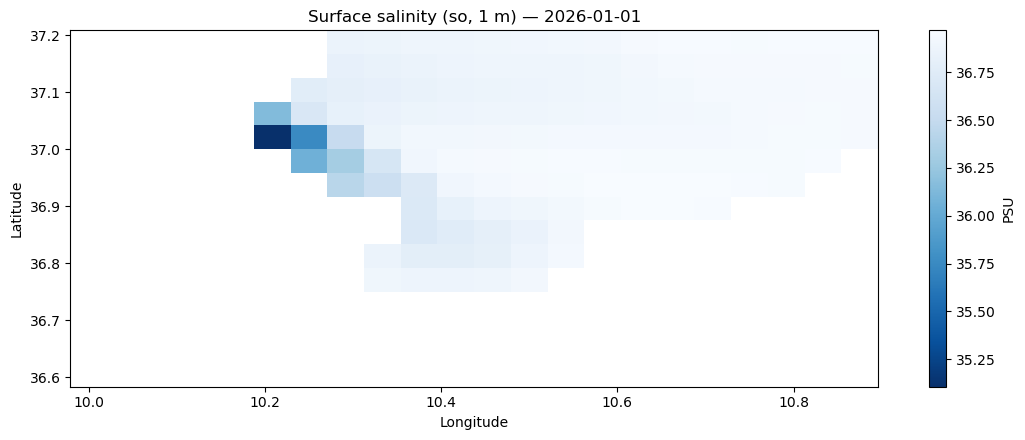

In [7]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(11, 4.5))
so.isel(time=0).plot(ax=ax, cmap="Blues_r", cbar_kwargs={"label": "PSU"})
ax.set_title(f"Surface salinity (so, 1 m) — {str(so.time.values[0])[:10]}")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.show()

## 5. Spatial map — salinity on the last day (2026-03-31)

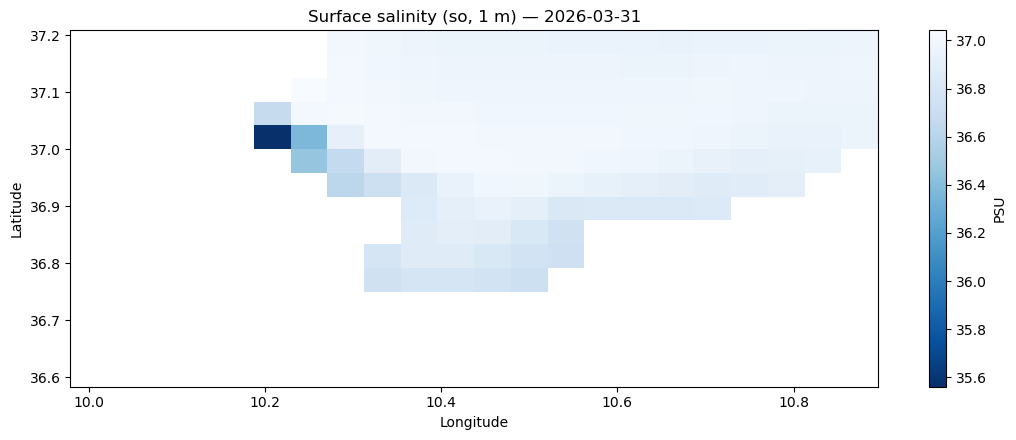

In [8]:
fig, ax = plt.subplots(figsize=(11, 4.5))
so.isel(time=-1).plot(ax=ax, cmap="Blues_r", cbar_kwargs={"label": "PSU"})
ax.set_title(f"Surface salinity (so, 1 m) — {str(so.time.values[-1])[:10]}")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.show()

## 6. Temporal mean map (Jan–Mar 2026)

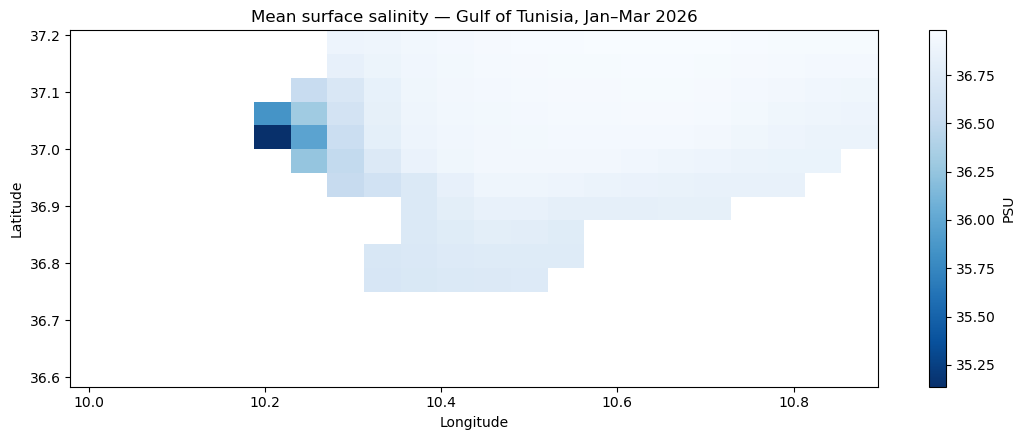

In [9]:
fig, ax = plt.subplots(figsize=(11, 4.5))
so.mean(dim="time").plot(ax=ax, cmap="Blues_r", cbar_kwargs={"label": "PSU"})
ax.set_title("Mean surface salinity — Gulf of Tunisia, Jan–Mar 2026")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.show()

## 7. Basin-averaged daily salinity time series

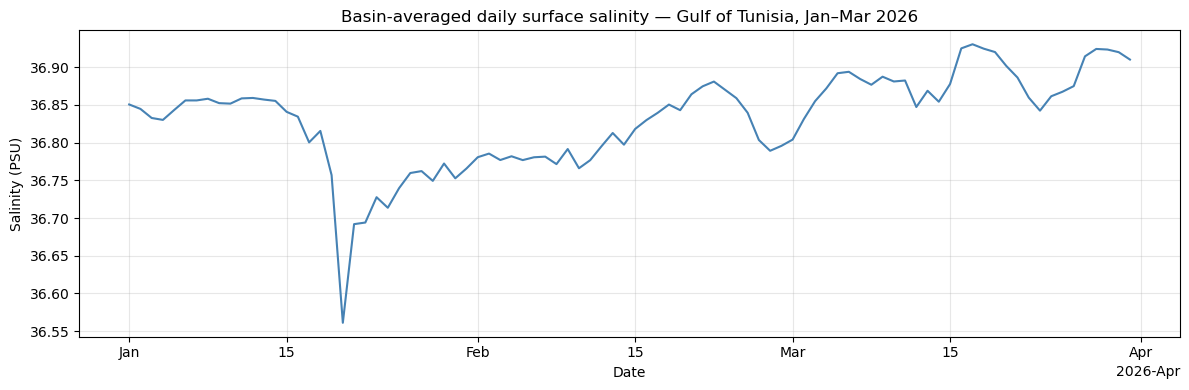

In [10]:
ts_sal = so.mean(dim=["latitude", "longitude"])

fig, ax = plt.subplots(figsize=(12, 4))
ts_sal.plot(ax=ax, color="steelblue", linewidth=1.5)
ax.set_ylabel("Salinity (PSU)")
ax.set_xlabel("Date")
ax.set_title("Basin-averaged daily surface salinity — Gulf of Tunisia, Jan–Mar 2026")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Spatial variability — standard deviation over time

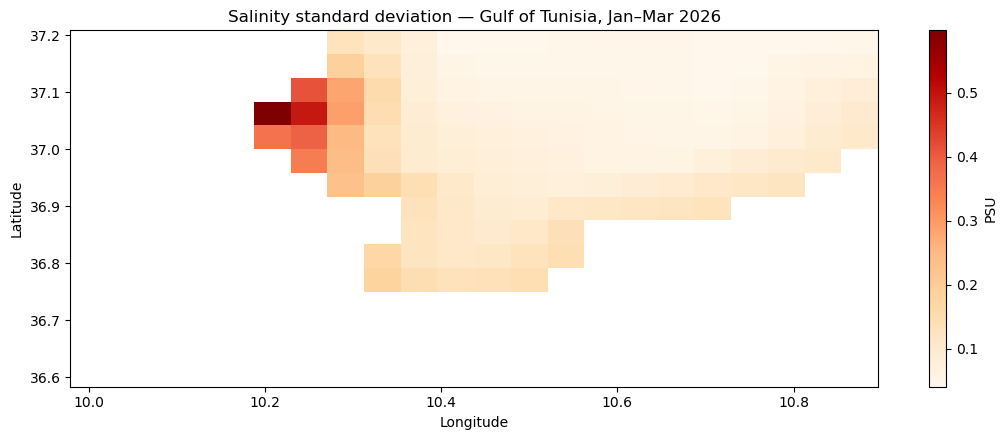

In [11]:
fig, ax = plt.subplots(figsize=(11, 4.5))
so.std(dim="time").plot(ax=ax, cmap="OrRd", cbar_kwargs={"label": "PSU"})
ax.set_title("Salinity standard deviation — Gulf of Tunisia, Jan–Mar 2026")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.show()

## 9. Interactive map with time slider (hvplot)

In [16]:
import hvplot.xarray  # noqa: F401
import panel as pn
pn.extension()

so.hvplot(
    x="longitude", y="latitude",
    groupby="time",
    rasterize=True,
    geo=True,
    tiles="OSM",
    cmap="turbo",
    clabel="PSU",
    clim=(float(so.min()), float(so.max())),
    title="Surface salinity (so, 1 m) — Gulf of Tunisia",
    width=700,
    height=500,
)

:DynamicMap   [time]
   :Overlay
      .WMTS.I  :WMTS   [Longitude,Latitude]
      .Image.I :Image   [longitude,latitude]   (salinity)

## 10. (Optional) Download the data as a local NetCDF file

In [ ]:
output_file = "cmems_salinity_tunisia_2026-Q1.nc"
so.to_netcdf(output_file)
print(f"Saved → {output_file}")